<h2 style="color:#9D2449; font-family:'Montserrat', sans-serif; font-size:42px; font-weight:700; margin-top:25px; margin-bottom:12px;">
Propuesta del índice de esfuerzo agrupando una nueva variable N=R+F
</h2>

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Carga de Datos
</h4>

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv("tramites_procesados.csv")

In [2]:
df["suma_N"]=df["I_formatos_norm"]+df["I_requisitos_norm"]

df["suma_N_z"] = (df["suma_N"] - df["suma_N"].mean()) / df["suma_N"].std()

df["indice_z2"] = (
    df["suma_N_z"] +
    df["indice_tiempo_z"] +
    df["digital_norm_z"] +
    df["costo_z"]
) / 4

df[["indice_z2", "suma_N_z", "digital_norm_z", "costo_z", "indice_tiempo_z"]].corr()

,indice_z2,suma_N_z,digital_norm_z,costo_z,indice_tiempo_z
indice_z2,1.000000,0.543231,0.389937,0.479367,0.468404
suma_N_z,0.543231,1.000000,-0.063191,0.108553,-0.023578
digital_norm_z,0.389937,-0.063191,1.000000,-0.157436,-0.045926
costo_z,0.479367,0.108553,-0.157436,1.000000,-0.049457
indice_tiempo_z,0.468404,-0.023578,-0.045926,-0.049457,1.000000


In [3]:
df[["indice_z2", "CONTEO_NETO", "N_FORMATOS_FINAL", "nivel_digitalizacion_numT", "costo", "Tiempo_en_minutos"]].corr()

,indice_z2,CONTEO_NETO,N_FORMATOS_FINAL,nivel_digitalizacion_numT,costo,Tiempo_en_minutos
indice_z2,1.000000,0.458906,0.410309,-0.389937,0.479367,0.322913
CONTEO_NETO,0.458906,1.000000,0.360923,0.091979,0.225646,0.041961
N_FORMATOS_FINAL,0.410309,0.360923,1.000000,-0.019608,0.038980,-0.027326
nivel_digitalizacion_numT,-0.389937,0.091979,-0.019608,1.000000,0.157436,-0.028423
costo,0.479367,0.225646,0.038980,0.157436,1.000000,-0.056578
Tiempo_en_minutos,0.322913,0.041961,-0.027326,-0.028423,-0.056578,1.000000


In [4]:
df_top = df.sort_values("indice_z2", ascending=False).head(10)
df_top

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,...,indice_tiempo_z,digital_norm_z,costo_z,indice_z,suma_N,suma_N_z,indice_z2,rank_z,rank_z2,cluster
572,1476.0,Autorización para Prestar Servicios de Segurid...,Secretaría de Seguridad Pública,Secretaría de Seguridad Pública,Boulevard S/N Fraccionamiento Colosio II 42039...,Ambos,14400.0,12.0,11.0,Nivel 1,...,0.892192,0.355848,0.655333,2.185991,2.000000,5.682390,1.896440,665.0,665.0,3
147,6717.0,Convocatoria del Instituto de Formación Profes...,Secretaría de Seguridad Pública,Secretaría de Seguridad Pública,Carretera Km. 0+500 San José Palma Gorda 42188...,Social,64800.0,3.0,15.0,Nivel 1,...,1.224080,0.355848,-1.523648,1.668471,1.881640,5.227145,1.320856,664.0,664.0,3
281,1506.0,Expedición de Tarjetón para Personas Conductor...,Secretaría de Movilidad y Transporte,Sistema de Transporte Masivo de Hidalgo,"Calle Km 1 Blvd. Camino a Téllez Km. 1, Jagüey...",Social,1440.0,2.0,13.0,Nivel 1,...,-0.118369,0.355848,0.655333,1.472596,1.591392,4.110771,1.250896,663.0,663.0,3
485,10549.0,Titulación en la UICEH,Secretaría de Educación Pública,Universidad Intercultural del Estado de Hidalgo,Carretera S/N EL DESDAVI 43487 El Desdavi Tena...,Social,518400.0,0.0,8.0,Nivel 1,...,2.536240,0.355848,0.655333,1.118187,0.868943,1.332039,1.219865,655.0,662.0,1
106,1541.0,Refrendo anual de registro de perito valuador,Secretaría de Hacienda,Instituto Catastral,Calle 105 Real de Minas 42090 Pachuca De Soto ...,NaN,172800.0,2.0,2.0,NaN,...,2.183949,0.649445,0.655333,1.137883,0.873567,1.349823,1.209637,656.0,661.0,3
289,1540.0,Inscripción de registro de perito valuador (Ca...,Secretaría de Hacienda,Instituto Catastral,Calle 105 Real de Minas 42090 Pachuca De Soto ...,NaN,172800.0,2.0,2.0,Nivel 1,...,2.183949,0.355848,0.655333,1.079164,0.873567,1.349823,1.136238,652.0,660.0,3
477,10079.0,Refrendo anual perito topográfo,Secretaría de Hacienda,Instituto Catastral,Calle 105 Real de Minas 42090 Pachuca De Soto ...,NaN,172800.0,2.0,1.0,NaN,...,2.183949,0.649445,0.655333,1.019835,0.774330,0.968132,1.114214,649.0,659.0,3
29,694.0,Autorregulación Ambiental,Secretaría de Medio Ambiente y Recursos Naturales,Secretaría de Medio Ambiente y Recursos Naturales,Calle 100 Adolfo López Mateos 42094 Pachuca De...,Social,36000.0,2.0,4.0,NaN,...,1.035599,0.649445,0.655333,1.143039,1.070972,2.109097,1.112368,658.0,658.0,3
236,1135.0,Registro Profesional Estatal,Secretaría de Educación Pública,Secretaría de Educación Pública,Circuito Lote 17 Ex Hacienda La Concepción 421...,Social,60.0,5.0,7.0,Nivel 2,...,-0.949438,0.062251,0.655333,1.399432,1.697776,4.519954,1.072025,661.0,657.0,3
648,8907.0,Constancia de terminación de estadía UPP,Secretaría de Educación Pública,Universidad Politécnica de Pachuca,Carretera S/N Santa Bárbara 43830 Zempoala Zem...,Social,4320.0,3.0,11.0,Nivel 2,...,0.506166,0.062251,-1.523648,1.466169,1.881640,5.227145,1.067978,662.0,656.0,3


In [5]:
df.sort_values("indice_z").head(10)

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,...,indice_tiempo_z,digital_norm_z,costo_z,indice_z,suma_N,suma_N_z,indice_z2,rank_z,rank_z2,cluster
426,8154.0,Becas UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,8.0,1.0,1.0,Nivel 4.1,...,-1.502325,-2.873716,-1.523648,-1.375435,0.360683,-0.622866,-1.630639,1.0,1.0,0
434,8299.0,Historial académico UTVM,Secretaría de Educación Pública,Universidad Tecnológica del Valle del Mezquital,Carretera S/N El Nith 42300 El Nith Ixmiquilpan,Social,2.0,0.0,1.0,Nivel 4.3,...,-0.447691,-3.460909,-1.523648,-1.290177,0.354106,-0.648164,-1.520103,2.0,2.0,0
31,6938.0,Historial académico UTT,Secretaría de Educación Pública,Universidad Tecnológica de Tulancingo,Calle 301 Las Presas 43642 Tulancingo De Bravo...,Social,1440.0,0.0,0.0,Nivel 4.2,...,-0.118369,-3.167312,-1.523648,-1.165593,0.354106,-0.648164,-1.364373,3.5,3.5,0
26,6935.0,Credencial Institucional UTT,Secretaría de Educación Pública,Universidad Tecnológica de Tulancingo,Calle 301 Las Presas 43642 Tulancingo De Bravo...,Social,1440.0,0.0,0.0,Nivel 4.2,...,-0.118369,-3.167312,-1.523648,-1.165593,0.354106,-0.648164,-1.364373,3.5,3.5,0
239,1142.0,Registro como unidad receptora de servicio social,Secretaría de Educación Pública,Secretaría de Educación Pública,Circuito Lote 17 Ex Hacienda La Concepción 421...,Ambos,1440.0,1.0,2.0,Nivel 4.1,...,-0.118369,-2.873716,-1.523648,-0.980595,0.459920,-0.241174,-1.189227,5.0,5.0,0
392,7446.0,Examen Toefl UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,-1.230621,-2.873716,0.655333,-0.893528,0.354106,-0.648164,-1.024292,7.5,7.5,0
394,7448.0,Examen Extraordinario UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,-1.230621,-2.873716,0.655333,-0.893528,0.354106,-0.648164,-1.024292,7.5,7.5,0
393,7447.0,Examen de Competencia Profesional UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,-1.230621,-2.873716,0.655333,-0.893528,0.354106,-0.648164,-1.024292,7.5,7.5,0
387,7434.0,Examen de Egreso de Licenciatura UPT,Secretaría de Educación Pública,Universidad Politécnica de Tulancingo,Calle 100 Huapalcalco 43629 Tulancingo De Brav...,Social,20.0,0.0,1.0,Nivel 4.1,...,-1.230621,-2.873716,0.655333,-0.893528,0.354106,-0.648164,-1.024292,7.5,7.5,0
296,1560.0,Preinscripciones de Educación Básica,Secretaría de Educación Pública,Instituto Hidalguense de Educación,Boulevard s/n Venta Prieta 42083 Pachuca De So...,Social,47520.0,0.0,1.0,Nivel 4.1,...,1.124625,-2.873716,-1.523648,-0.858275,0.354106,-0.648164,-0.980226,10.0,10.0,0


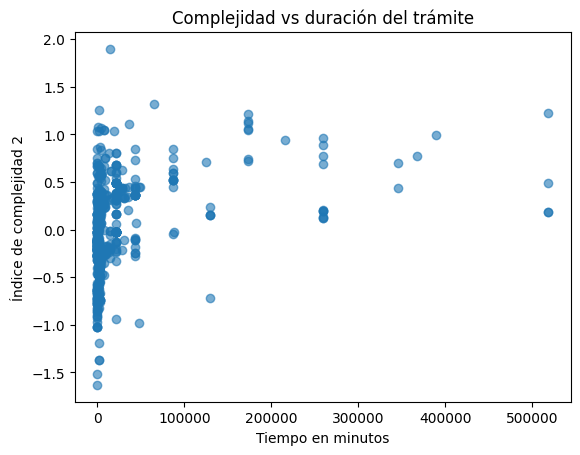

In [6]:
plt.scatter(df["Tiempo_en_minutos"], df["indice_z2"], alpha=0.6)
plt.xlabel("Tiempo en minutos")
plt.ylabel("Índice de complejidad 2")
plt.title("Complejidad vs duración del trámite")
plt.show()

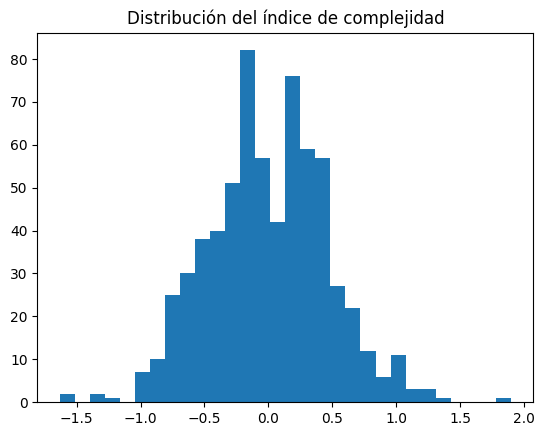

In [7]:
plt.hist(df["indice_z2"], bins=30)
plt.title("Distribución del índice de complejidad")
plt.show()

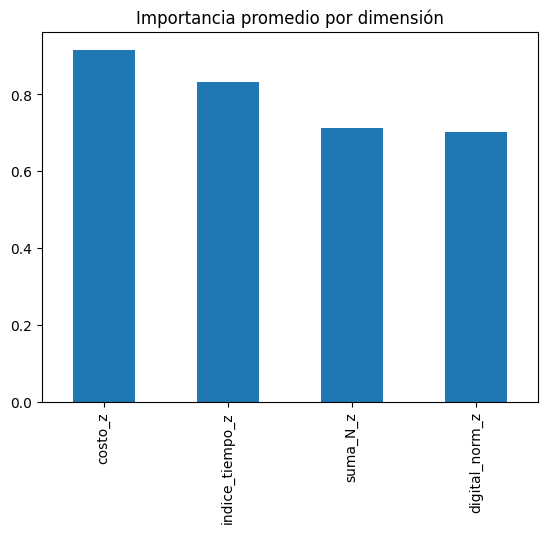

In [8]:
cols = [
    "suma_N_z",
    "indice_tiempo_z",
    "digital_norm_z",
    "costo_z"
]

df[cols].abs().mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Importancia promedio por dimensión")
plt.show()

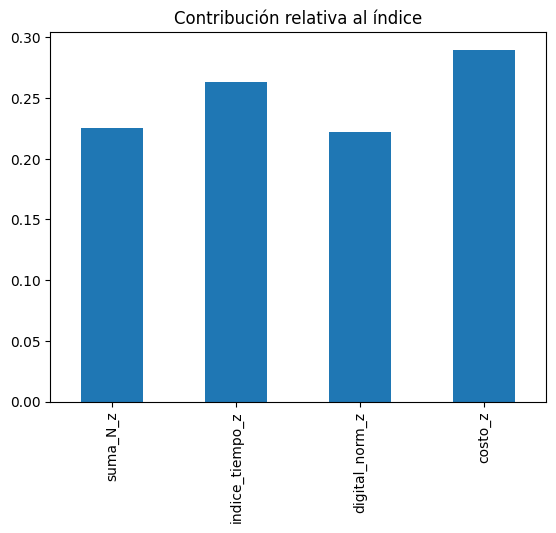

In [9]:
contrib = df[cols].abs().mean()
contrib = contrib / contrib.sum()

contrib.plot(kind="bar")
plt.title("Contribución relativa al índice")
plt.show()

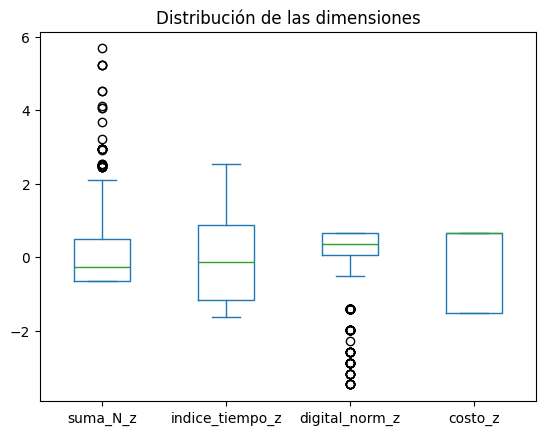

In [10]:
df[[
    "suma_N_z",
    "indice_tiempo_z",
    "digital_norm_z",
    "costo_z"
]].plot(kind="box")
plt.title("Distribución de las dimensiones")
plt.show()

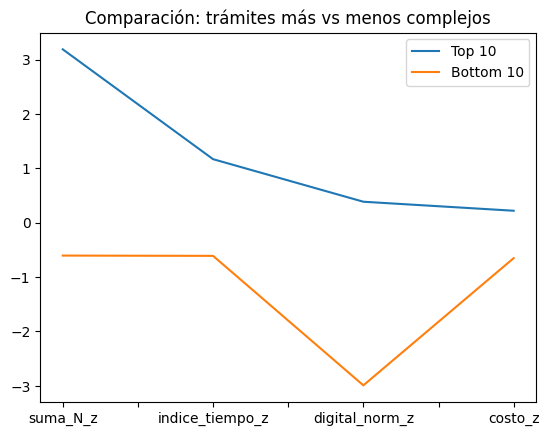

In [11]:
top = df.sort_values("indice_z2", ascending=False).head(10)
bottom = df.sort_values("indice_z2").head(10)

top[cols].mean().plot(label="Top 10")
bottom[cols].mean().plot(label="Bottom 10")

plt.legend()
plt.title("Comparación: trámites más vs menos complejos")
plt.show()

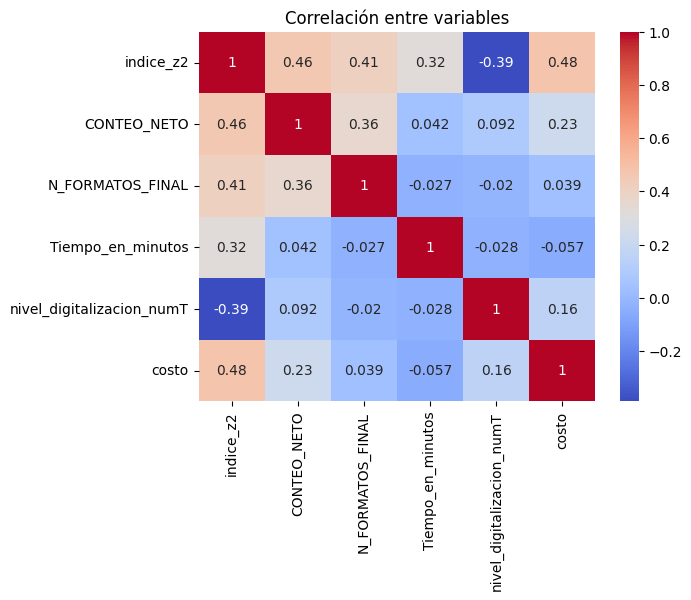

In [12]:
sns.heatmap(df[[
    "indice_z2",
    "CONTEO_NETO",
    "N_FORMATOS_FINAL",
    "Tiempo_en_minutos",
    "nivel_digitalizacion_numT",
    "costo"
]].corr(), annot=True, cmap="coolwarm")

plt.title("Correlación entre variables")
plt.show()

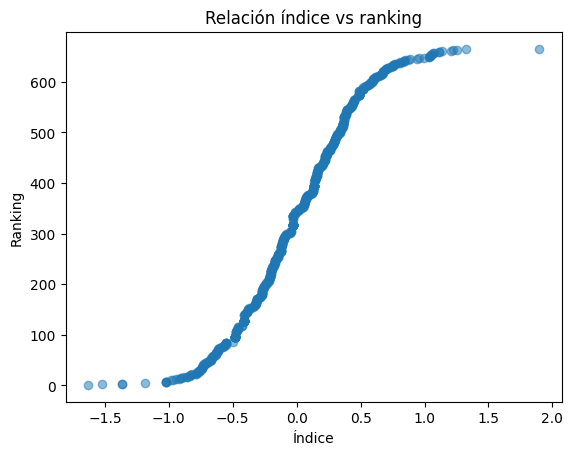

In [13]:
plt.scatter(df["indice_z2"], df["rank_z2"], alpha=0.5)
plt.xlabel("Índice")
plt.ylabel("Ranking")
plt.title("Relación índice vs ranking")
plt.show()

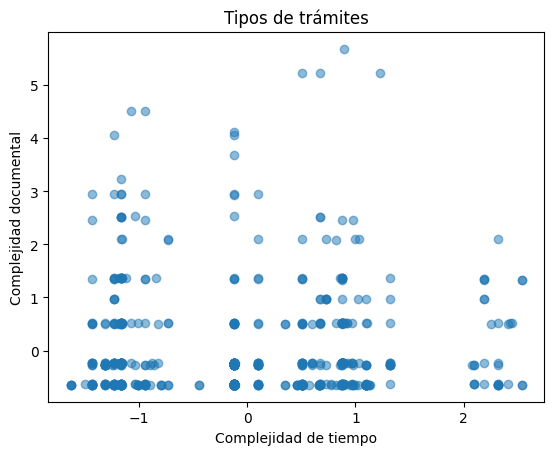

In [14]:
plt.scatter(
    df["indice_tiempo_z"],
    df["suma_N_z"],
    alpha=0.5
)

plt.xlabel("Complejidad de tiempo")
plt.ylabel("Complejidad documental")
plt.title("Tipos de trámites")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(df[cols])

df.groupby("cluster")[cols].mean()

,suma_N_z,indice_tiempo_z,digital_norm_z,costo_z
cluster,,,,
0,0.120573,0.228908,-2.142494,0.470325
1,0.058591,-0.100223,0.412493,0.655333
2,-0.179802,0.066062,0.394277,-1.523648


In [16]:
df["cluster"].value_counts()

cluster
1    368
2    191
0    106
Name: count, dtype: int64

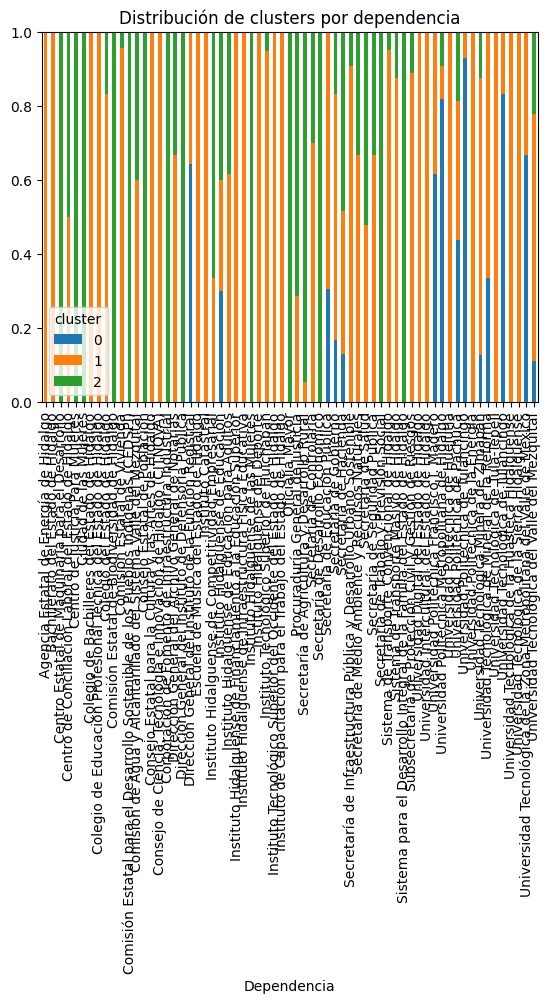

In [17]:
tabla = pd.crosstab(df["Dependencia"], df["cluster"])
tabla_prop = tabla.div(tabla.sum(axis=1), axis=0)
tabla_prop.plot(kind="bar", stacked=True)
plt.title("Distribución de clusters por dependencia")
plt.show()

In [18]:
tabla_prop

cluster,0,1,2
Dependencia,,,
Agencia Estatal de Energía de Hidalgo,0.000000,1.000000,0.000000
Bachillerato del Estado de Hidalgo,0.000000,1.000000,0.000000
Centro Estatal de Maquinaria para el Desarrollo,0.000000,0.000000,1.000000
Centro de Conciliación Laboral del Estado de Hidalgo,0.000000,0.500000,0.500000
Centro de Justicia Para Mujeres,0.000000,0.000000,1.000000
...,...,...,...
Universidad Tecnológica de Tulancingo,0.833333,0.166667,0.000000
Universidad Tecnológica de la Huasteca Hidalguense,0.000000,1.000000,0.000000
Universidad Tecnológica de la Sierra Hidalguense,0.000000,1.000000,0.000000


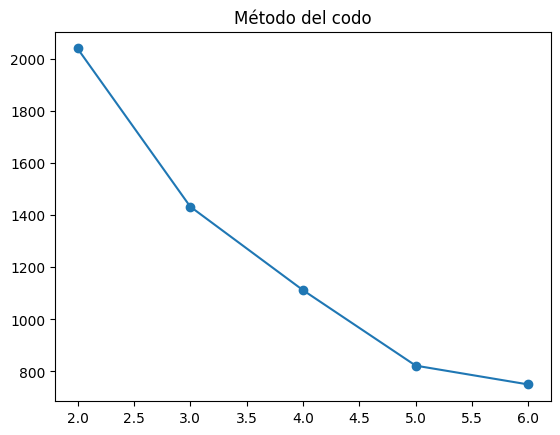

In [19]:
inertia = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df[cols])
    inertia.append(km.inertia_)

plt.plot(range(2, 7), inertia, marker='o')
plt.title("Método del codo")
plt.show()

In [20]:
df.groupby("cluster")[cols].mean()

,suma_N_z,indice_tiempo_z,digital_norm_z,costo_z
cluster,,,,
0,0.120573,0.228908,-2.142494,0.470325
1,0.058591,-0.100223,0.412493,0.655333
2,-0.179802,0.066062,0.394277,-1.523648


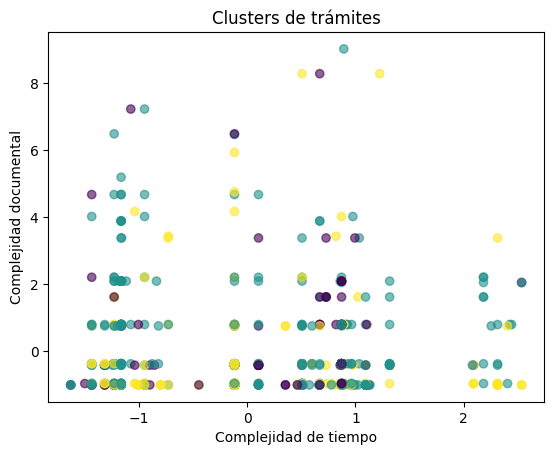

In [21]:
plt.scatter(
    df["indice_tiempo_z"],
    df["I_requisitos_norm_z"] + df["I_formatos_norm_z"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Complejidad de tiempo")
plt.ylabel("Complejidad documental")
plt.title("Clusters de trámites")
plt.show()

In [22]:
cols = [
    "CONTEO_NETO",
    "N_FORMATOS_FINAL",
    "Tiempo_en_minutos",
    "nivel_digitalizacion_numT",
    "costo"
]

In [23]:
df_export = df[[
    "Tramite",
    "Secretaria",
    "Dependencia",
    "Tiempo_en_minutos",
    "CONTEO_NETO",
    "N_FORMATOS_FINAL",
    "nivel_digitalizacion",
    "costo",
    "cluster",
    "indice_z2"
]]

df_export.to_csv("tramites_clusters2.csv", index=False)